# 03 · Transformaciones y reflexión final

**Qué hace este notebook:** toma lo que dejó el primer notebook en `data/interim/`, aplica las decisiones del diagnóstico de calidad (segundo notebook) y arma el **dataset final a nivel estación × hora**, listo para modelar. No se entrena ningún modelo.

**Entradas:** `viajes.parquet`, `fotos_hora.parquet` y `clima.parquet` (en `data/interim/`), `data/feriados.csv` y, sólo para las coordenadas, las fotos crudas.

**Salida:** `data/processed/dataset_estacion_hora.parquet`, más una tabla de estaciones y los parámetros de la normalización.

**Target.** Los **retiros** (y arribos) **reales** de BA Data por estación y hora. El proxy construido con las fotos se usó en el segundo notebook sólo para validar la confiabilidad; como target no sirve en 2026 (captura el 22 % de los retiros entre febrero y agosto).

## 0. Configuración

- **`DATA_DIR`:** carpeta con los datos crudos, igual que en el primer notebook. Acá sólo se usa para leer las coordenadas de las estaciones desde las fotos.
- **Período del dataset:** del 01/01/2024 a las 00 h al 31/08/2026 a las 23 h, que es el período con viajes publicados.
- **Corte de test:** desde el 01/06/2026 (junio a agosto de 2026), como indica el plan.

In [1]:
from pathlib import Path
import json
import os

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

REPO_DIR = Path("..").resolve()
DATA_DIR = Path(os.environ.get("ECOBICI_DATA_DIR", REPO_DIR / "datasets")).resolve()
FOTOS_DIR = DATA_DIR / "archive" / "stations" / "buenos-aires" / "ecobici"

INTERIM_DIR = REPO_DIR / "data" / "interim"
PROCESSED_DIR = REPO_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TZ = "America/Argentina/Buenos_Aires"
INICIO = pd.Timestamp("2024-01-01 00:00", tz=TZ)
FIN = pd.Timestamp("2026-08-31 23:00", tz=TZ)
TEST_DESDE = pd.Timestamp("2026-06-01 00:00", tz=TZ)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})

for ruta in [INTERIM_DIR / "viajes.parquet", INTERIM_DIR / "fotos_hora.parquet",
             INTERIM_DIR / "clima.parquet", REPO_DIR / "data" / "feriados.csv", FOTOS_DIR]:
    assert ruta.exists(), f"No se encontró {ruta}. Correr antes el notebook 01."
con = duckdb.connect()  # sólo para leer archivos pesados
print("Entradas:", INTERIM_DIR)
print("Salidas: ", PROCESSED_DIR)

Entradas: /Users/juan.fernandez/itba/cda/ecobici-demand-predictor/.claude/worktrees/code-review-consigna-notebooks-9f6cbd/data/interim
Salidas:  /Users/juan.fernandez/itba/cda/ecobici-demand-predictor/.claude/worktrees/code-review-consigna-notebooks-9f6cbd/data/processed


## 1. Carga de los datos intermedios

De los viajes sólo se leen las columnas que hacen falta para contar retiros y arribos. Nombres, direcciones, usuario, modelo de bici y género no se usan en el dataset por estación y hora (ver la sección 10), así que no se cargan: ahorra memoria con 8,7 M de filas.

In [2]:
COLUMNAS_VIAJES = ["anio_archivo", "id_recorrido", "duracion_seg", "fecha_origen", "id_estacion_origen",
                   "fecha_destino", "id_estacion_destino", "lat_estacion_origen", "long_estacion_origen"]
viajes = pd.read_parquet(INTERIM_DIR / "viajes.parquet", columns=COLUMNAS_VIAJES)
fotos_hora = pd.read_parquet(INTERIM_DIR / "fotos_hora.parquet")
clima = pd.read_parquet(INTERIM_DIR / "clima.parquet")
feriados = pd.read_csv(REPO_DIR / "data" / "feriados.csv", parse_dates=["fecha"])

pd.DataFrame({
    "filas": [len(viajes), len(fotos_hora), len(clima), len(feriados)],
    "columnas": [viajes.shape[1], fotos_hora.shape[1], clima.shape[1], feriados.shape[1]],
}, index=["viajes", "fotos_hora", "clima", "feriados"])

,filas,columnas
viajes,8695091,9
fotos_hora,6708782,13
clima,23856,4
feriados,58,3


## 2. Limpieza

Se aplican las acciones del inventario de calidad (sección 7 del segundo notebook).

### 2.1 Viajes

| Regla | Evidencia (notebook 02) | Decisión |
|---|---|---|
| `id_recorrido` duplicado | 1 fila repetida exacta en 2024 | `drop_duplicates` |
| Duración < 61 s | 9,1 % de los viajes de 2024 y **ninguno** desde 2025: BA Data empezó a filtrarlos | Mínimo común a todos los años: se descartan en 2024 |
| Misma estación y < 2 min | 7,3 % en 2024, < 1 % en 2025–2026 | No es un viaje sino una bici rechazada o un error de anclaje: se descarta |
| Duración > 24 h | Máximos de ~30 días | Bicis no devueltas o viajes cerrados por el sistema: se descartan |
| Estaciones que no están en el feed GBFS | 5 estaciones (tabla de abajo) | No son estaciones públicas: por el nombre son depósitos, un taller y un galpón. Se descartan los viajes que salen de ellas o llegan a ellas |
| `fecha_destino` nula | 3.379 viajes de 2024 | Todos duran menos de 61 s, así que ya los saca la regla de duración. Se verifica después del filtro |

In [3]:
estaciones_feed = set(fotos_hora.station_id.unique())
ids_viajes = set(viajes.id_estacion_origen.unique()) | set(viajes.id_estacion_destino.dropna().astype("int64").unique())
ESTACIONES_NO_PUBLICAS = sorted(ids_viajes - estaciones_feed)
con.sql(f'''
    SELECT id_estacion_destino                    AS station_id,
           any_value(nombre_estacion_destino)     AS nombre,
           any_value(lat_estacion_destino)        AS latitud,
           count(*)                               AS arribos,
           (SELECT count(*) FROM read_parquet('{(INTERIM_DIR / "viajes.parquet").as_posix()}') o
             WHERE o.id_estacion_origen = d.id_estacion_destino) AS retiros
    FROM read_parquet('{(INTERIM_DIR / "viajes.parquet").as_posix()}') d
    WHERE id_estacion_destino IN ({", ".join(map(str, ESTACIONES_NO_PUBLICAS))})
    GROUP BY 1 ORDER BY 1
''').df()

,station_id,nombre,latitud,arribos,retiros
0,294,363 - Udaondo,-34.547131,9,0
1,313,291 - REPARACION DE K7,-34.565003,11,0
2,402,-- CDO Chacarita -- (Temporal),-34.597612,2,0
3,443,-CDO CUCHA CUCHA-,-34.654474,1657,1163
4,510,[Valet] Galpón,0.000000,270,0


In [4]:
n_inicial = len(viajes)
viajes = viajes.drop_duplicates("id_recorrido")
print(f"Duplicados de id_recorrido eliminados: {n_inicial - len(viajes)}")

reglas = pd.DataFrame({
    "duración < 61 s": viajes.duracion_seg < 61,
    "misma estación y < 2 min": (viajes.id_estacion_origen == viajes.id_estacion_destino) & (viajes.duracion_seg < 120),
    "duración > 24 h": viajes.duracion_seg > 24 * 3600,
    "estación no pública": viajes.id_estacion_origen.isin(ESTACIONES_NO_PUBLICAS)
                           | viajes.id_estacion_destino.isin(ESTACIONES_NO_PUBLICAS),
})
reglas["descartado (alguna regla)"] = reglas.any(axis=1)

descartes = reglas.groupby(viajes.anio_archivo).sum()
descartes.insert(0, "viajes", viajes.groupby("anio_archivo").size())
descartes.loc["total"] = descartes.sum()
descartes["% descartado"] = (descartes["descartado (alguna regla)"] / descartes["viajes"] * 100).round(2)
descartes

Duplicados de id_recorrido eliminados: 1


,viajes,duración < 61 s,misma estación y < 2 min,duración > 24 h,estación no pública,descartado (alguna regla),% descartado
anio_archivo,,,,,,,
2024,3559283,325034,258520,687,1085,351660,9.88
2025,3156182,0,28428,398,897,29621,0.94
2026,1979625,0,18777,181,745,19670,0.99
total,8695090,325034,305725,1266,2727,400951,4.61


Las reglas se superponen (casi todas las vueltas a la misma estación en menos de 2 min de 2024 duran además menos de 61 s), por eso la última columna no es la suma de las anteriores.

In [5]:
viajes = viajes[~reglas["descartado (alguna regla)"]].copy()

print(f"Viajes con fecha_destino nula que quedaron: {viajes.fecha_destino.isna().sum()}")
assert viajes.fecha_destino.notna().all()

(viajes.groupby("anio_archivo").duracion_seg.describe(percentiles=[.5]) / 60).round(1).assign(
    count=viajes.groupby("anio_archivo").size()).rename(columns=lambda c: c if c == "count" else f"{c} (min)")

Viajes con fecha_destino nula que quedaron: 0


,count,mean (min),std (min),min (min),50% (min),max (min)
anio_archivo,,,,,,
2024,3207623,21.9,29.0,1.0,16.2,1439.1
2025,3126561,22.5,30.7,1.0,16.3,1436.2
2026,1959955,22.6,29.8,1.0,16.3,1435.8


**Lectura.** Después de la limpieza los tres años tienen el mismo mínimo (61 s ≈ 1 min) y el mismo máximo (24 h), así que la demanda de 2024 ya se puede comparar con la de 2025 y 2026. En 2024 se pierde ~10 % de las filas, pero no eran viajes.

### 2.2 Fotos por hora

| Regla | Evidencia | Decisión |
|---|---|---|
| Fragmento de abril de 2024 | 43 horas (10/04 18 h → 12/04 11 h) aisladas antes de un hueco de 132 días | Se descartan: dos días sueltos no describen ese período y en esas fotos hay estaciones con otro nombre (358 *Balbín* → *Vidal*) |
| Fotos con `capacity = 0` | 2.644 estación-hora, 259 estaciones; la 571 (*Pedro Lozano*) siempre tiene 0 y no registra viajes | La foto no es válida (estación deshabilitada o error del feed). Se descarta la estación-hora, que pasa a ser una hora **sin fotos** |
| Fotos con `is_renting = False` | 425 estación-hora, 19 estaciones | **No se descartan.** La estación estaba cerrada: si no hubo retiros fue por eso y no por falta de demanda. Quedan como flag de demanda censurada (`sin_alquiler`, sección 5) |
| `external_id`, `short_name` | 89 % y 99 % faltantes | Ya no están: el primer notebook no los incluyó al agregar por hora |

In [6]:
n_antes = len(fotos_hora)
fragmento_abril = fotos_hora.hora_local < pd.Timestamp("2024-08-01")
capacidad_cero = fotos_hora.n_fotos_capacidad_cero > 0

pd.Series({
    "estación-hora al inicio": n_antes,
    "fragmento de abril de 2024": fragmento_abril.sum(),
    "alguna foto con capacity = 0": (capacidad_cero & ~fragmento_abril).sum(),
    "con alguna foto is_renting = False (se conservan)": (fotos_hora.n_fotos_sin_alquiler > 0).sum(),
}).to_frame("estación-hora")

,estación-hora
estación-hora al inicio,6708782
fragmento de abril de 2024,14743
alguna foto con capacity = 0,2642
con alguna foto is_renting = False (se conservan),425


In [7]:
fotos_hora = fotos_hora[~fragmento_abril & ~capacidad_cero].drop(columns="n_fotos_capacidad_cero")
print(f"Estación-hora con fotos después de la limpieza: {len(fotos_hora):,} "
      f"({(n_antes - len(fotos_hora)) / n_antes:.2%} descartado)")

Estación-hora con fotos después de la limpieza: 6,691,397 (0.26% descartado)


### 2.3 Coordenadas de las estaciones y signo de la latitud

El dataset final lleva la ubicación de cada estación como variable espacial. Se toma de las fotos crudas (feed oficial). En el segundo notebook se vio que la estación **066 – Billinghurst** tiene la latitud con el signo invertido entre octubre y diciembre de 2024: Buenos Aires está en el hemisferio sur, así que toda latitud válida es negativa y la corrección es `-abs(latitud)`.

Las estaciones se mueven (el 10 % más de ~170 m), así que se usa la **última coordenada** publicada. DuckDB se usa acá sólo para leer y agregar las 21 M de fotos.

In [8]:
coordenadas = con.sql(f'''
    SELECT TRY_CAST(station_id AS INTEGER)                      AS station_id,
           arg_max(name, committed_at_utc)                      AS nombre,
           count(*) FILTER (WHERE latitude > 0)                 AS fotos_latitud_positiva,
           max(latitude)                                        AS latitud_max_cruda,
           max(-abs(latitude))                                  AS latitud_max_corregida,
           arg_max(-abs(latitude), committed_at_utc)            AS lat,
           arg_max(longitude, committed_at_utc)                 AS lon
    FROM read_parquet('{FOTOS_DIR.as_posix()}/*/*.parquet')
    GROUP BY 1
''').df()
coordenadas[coordenadas.fotos_latitud_positiva > 0]

,station_id,nombre,fotos_latitud_positiva,latitud_max_cruda,latitud_max_corregida,lat,lon
27,66,066 - Billinghurst,5265,34.594547,-34.594547,-34.594547,-58.413871


In [9]:
en_caba = coordenadas.lat.between(-34.75, -34.5) & coordenadas.lon.between(-58.55, -58.33)
print(f"Estaciones con coordenadas dentro de CABA después de corregir: {en_caba.sum()} de {len(coordenadas)}")

# Control cruzado: última coordenada de origen en los viajes (que no tienen el error de signo)
ultimo_viaje = viajes.sort_values("fecha_origen").groupby("id_estacion_origen").last()
control = coordenadas.set_index("station_id").join(ultimo_viaje[["lat_estacion_origen", "long_estacion_origen"]], how="inner")
distancia_m = np.hypot((control.lat - control.lat_estacion_origen) * 111_000,
                       (control.lon - control.long_estacion_origen) * 111_000 * np.cos(np.radians(34.6)))
print(f"Estaciones comparadas: {len(distancia_m)} · distancia máxima entre fotos y viajes: {distancia_m.max():.1f} m")

estaciones = coordenadas[["station_id", "nombre", "lat", "lon"]]
viajes = viajes.drop(columns=["lat_estacion_origen", "long_estacion_origen"])

Estaciones con coordenadas dentro de CABA después de corregir: 414 de 414


Estaciones comparadas: 413 · distancia máxima entre fotos y viajes: 0.0 m


**Lectura.** La latitud positiva aparece en una sola estación (la 066) y desaparece con la corrección. La coordenada de las fotos coincide **exactamente** con la de los viajes en todas las estaciones con retiros: BA Data usa el mismo catálogo de estaciones que el feed, y el error de signo sólo está en las fotos.

### 2.4 Zonas horarias

Las tres fuentes ya están en hora de Buenos Aires, pero sin la zona horaria marcada:

- **Viajes:** BA Data publica en hora local (el segundo notebook lo confirmó: la correlación con las fotos es máxima sin desplazamiento).
- **Fotos:** el primer notebook las pasó de UTC a hora local antes de truncar a la hora.
- **Clima:** se pidió a Open-Meteo con `timezone = America/Argentina/Buenos_Aires`.

Se marca la zona horaria en las tres con `tz_localize`, para que un error de zona horaria haga fallar el `merge` en lugar de desplazar los datos en silencio. Argentina no tiene horario de verano, así que no hay horas ambiguas ni inexistentes.

In [10]:
viajes["hora_origen"] = viajes.fecha_origen.dt.floor("h").dt.tz_localize(TZ)
viajes["hora_destino"] = viajes.fecha_destino.dt.floor("h").dt.tz_localize(TZ)
fotos_hora["hora_local"] = fotos_hora.hora_local.dt.tz_localize(TZ)
clima["hora_local"] = clima.hora_local.dt.tz_localize(TZ)

for nombre, serie in [("viajes (origen)", viajes.hora_origen), ("viajes (destino)", viajes.hora_destino),
                      ("fotos_hora", fotos_hora.hora_local), ("clima", clima.hora_local)]:
    print(f"{nombre:17} {str(serie.dtype):45} NaT: {serie.isna().sum()}  {serie.min()} → {serie.max()}")

viajes (origen)   datetime64[us, America/Argentina/Buenos_Aires] NaT: 0  2024-01-01 00:00:00-03:00 → 2026-08-31 23:00:00-03:00
viajes (destino)  datetime64[us, America/Argentina/Buenos_Aires] NaT: 0  2024-01-01 00:00:00-03:00 → 2026-09-01 06:00:00-03:00
fotos_hora        datetime64[us, America/Argentina/Buenos_Aires] NaT: 0  2024-08-22 11:00:00-03:00 → 2026-09-27 11:00:00-03:00
clima             datetime64[ns, America/Argentina/Buenos_Aires] NaT: 0  2024-01-01 00:00:00-03:00 → 2026-09-20 23:00:00-03:00


## 3. Target: retiros y arribos por estación y hora

- **Retiros:** viajes que salen de la estación en esa hora (estación y hora de origen).
- **Arribos:** viajes que llegan a la estación en esa hora (estación y hora de destino).

**La grilla completa es la transformación clave.** Un `groupby` sobre los viajes sólo devuelve las estación-hora en las que hubo al menos un viaje: las horas con **0 retiros**, que son la mayoría, directamente no existirían y un modelo entrenado así nunca vería un cero. Por eso se arma primero la grilla de **todas las horas de cada estación activa** y después se unen los conteos, rellenando con 0.

**Estación activa:** desde la hora de su primer viaje (retiro o arribo) hasta la de su último viaje, con tope en el 31/08/2026 a las 23 h. Así una estación inaugurada en 2026 no suma ceros de 2024, cuando todavía no existía.

In [11]:
retiros = (viajes.groupby(["id_estacion_origen", "hora_origen"]).size()
                 .rename("retiros").rename_axis(["station_id", "hora_local"]).reset_index())
arribos = (viajes.dropna(subset=["id_estacion_destino"])
                 .groupby(["id_estacion_destino", "hora_destino"]).size()
                 .rename("arribos").rename_axis(["station_id", "hora_local"]).reset_index())
arribos["station_id"] = arribos.station_id.astype("int64")

ventana = (pd.concat([retiros[["station_id", "hora_local"]], arribos[["station_id", "hora_local"]]])
             .groupby("station_id").hora_local.agg(desde="min", hasta="max"))
ventana["hasta"] = ventana.hasta.clip(upper=FIN)
ventana["horas"] = ((ventana.hasta - ventana.desde).dt.total_seconds() // 3600).astype(int) + 1
print(f"Estaciones activas: {len(ventana)} · estación-hora en la grilla: {ventana.horas.sum():,}")
ventana.sort_values("desde", ascending=False).head()

Estaciones activas: 413 · estación-hora en la grilla: 8,999,075


,desde,hasta,horas
station_id,,,
343,2026-07-17 21:00:00-03:00,2026-08-31 23:00:00-03:00,1083
598,2026-03-30 23:00:00-03:00,2026-08-31 20:00:00-03:00,3694
596,2026-01-27 19:00:00-03:00,2026-08-31 18:00:00-03:00,5184
597,2026-01-27 14:00:00-03:00,2026-08-31 19:00:00-03:00,5190
594,2025-12-18 18:00:00-03:00,2026-08-31 21:00:00-03:00,6148


In [12]:
grilla = pd.concat(
    [pd.DataFrame({"station_id": estacion, "hora_local": pd.date_range(fila.desde, fila.hasta, freq="h")})
     for estacion, fila in ventana.iterrows()],
    ignore_index=True,
)
grilla = (grilla.merge(retiros, on=["station_id", "hora_local"], how="left")
                .merge(arribos, on=["station_id", "hora_local"], how="left"))
print(f"Estación-hora con al menos un retiro (lo que daría un groupby): {grilla.retiros.notna().sum():,}")
grilla[["retiros", "arribos"]] = grilla[["retiros", "arribos"]].fillna(0).astype("int16")
print(f"Estación-hora en la grilla completa:                          {len(grilla):,}")
print(f"Filas con 0 retiros: {(grilla.retiros == 0).mean():.1%}")

arribos_fuera = len(viajes) - grilla.arribos.sum() - viajes.id_estacion_destino.isna().sum()
assert grilla.retiros.sum() == len(viajes), "Se perdieron retiros al armar la grilla"
print(f"Control: retiros en la grilla = viajes limpios = {grilla.retiros.sum():,}")
print(f"Arribos fuera de la grilla (llegan después del 31/08/2026 a las 23 h): {arribos_fuera}")

Estación-hora con al menos un retiro (lo que daría un groupby): 3,616,253
Estación-hora en la grilla completa:                          8,999,075
Filas con 0 retiros: 59.8%
Control: retiros en la grilla = viajes limpios = 8,294,139
Arribos fuera de la grilla (llegan después del 31/08/2026 a las 23 h): 62


**Horas sin ningún viaje en toda la red.** Con ~400 estaciones, que en una hora no haya ni un retiro ni un arribo en toda la red indica un corte del sistema o un hueco en la publicación, no falta de demanda. Esas horas se sacan de la grilla: rellenarlas con 0 enseñaría al modelo una demanda nula que nunca ocurrió.

In [13]:
red = grilla.groupby("hora_local")[["retiros", "arribos"]].sum()
horas_corte = red.index[(red.retiros == 0) & (red.arribos == 0)]
print(f"Horas sin viajes en toda la red: {len(horas_corte)}")
print(pd.Series(horas_corte.strftime("%Y-%m-%d %H h")).groupby(horas_corte.date).agg(["size", "first", "last"]))

grilla = grilla[~grilla.hora_local.isin(horas_corte)].reset_index(drop=True)
print(f"\nGrilla sin esas horas: {len(grilla):,} estación-hora")

Horas sin viajes en toda la red: 19
            size            first             last
2024-05-25     5  2024-05-25 19 h  2024-05-25 23 h
2024-05-26    14  2024-05-26 00 h  2024-05-26 13 h

Grilla sin esas horas: 8,992,349 estación-hora


,count,mean,std,min,50%,75%,90%,99%,max
retiros,8992349.0,0.92,1.65,0.0,0.0,1.0,3.0,7.0,43.0
arribos,8992349.0,0.92,1.63,0.0,0.0,1.0,3.0,7.0,39.0


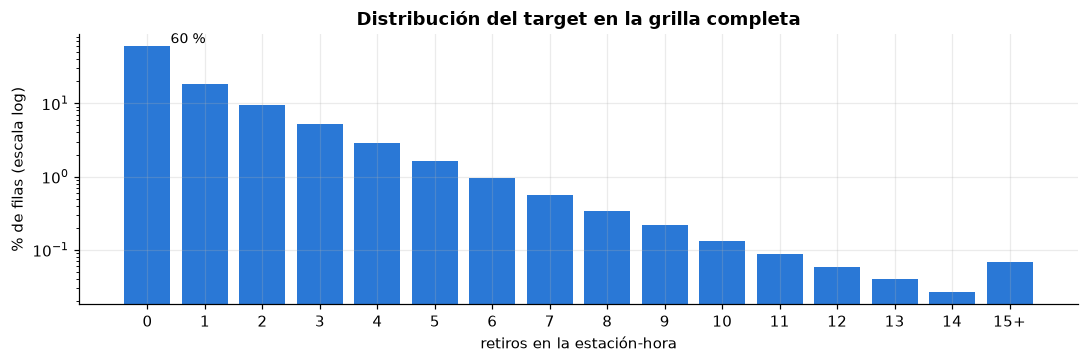

In [14]:
distribucion = grilla.retiros.clip(upper=15).value_counts(normalize=True).sort_index() * 100
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(distribucion.index, distribucion.values, color=BLUE, width=0.8)
ax.set_yscale("log")
ax.set_xticks(distribucion.index, [str(i) if i < 15 else "15+" for i in distribucion.index])
ax.set(xlabel="retiros en la estación-hora", ylabel="% de filas (escala log)",
       title="Distribución del target en la grilla completa")
ax.text(0.4, distribucion.iloc[0], f"{distribucion.iloc[0]:.0f} %", va="bottom", fontsize=9)
plt.tight_layout()
grilla[["retiros", "arribos"]].describe(percentiles=[.5, .75, .9, .99]).round(2).T

**Lectura.** El target es un conteo con **exceso de ceros**: la mayoría de las estación-hora no tiene retiros y la mediana es 0. Justamente por eso la grilla con ceros es imprescindible. Para modelar conviene una pérdida pensada para conteos (Poisson o Tweedie) y métricas que no se distorsionen con los ceros, como el MAE.

**Pendiente del plan: último día de los viajes de 2026.** El último retiro publicado es del **31/08/2026 a las 23:59** (confirmado en el primer notebook). Septiembre de 2026 todavía no está publicado, así que el dataset termina el 31/08/2026 a las 23 h.

## 4. Integración

### 4.1 Validación de las claves

Antes de cada `merge` se mide qué porcentaje de la grilla encuentra pareja en la otra tabla. Un porcentaje bajo e inesperado indicaría claves con distinto tipo, zona horaria o identificador.

In [15]:
claves_fotos = pd.MultiIndex.from_frame(fotos_hora[["station_id", "hora_local"]])
claves_grilla = pd.MultiIndex.from_frame(grilla[["station_id", "hora_local"]])
fechas_grilla = grilla.hora_local.dt.tz_localize(None).dt.normalize()

validacion = pd.DataFrame([
    ("estaciones", "grilla → fotos", grilla.station_id.drop_duplicates().isin(fotos_hora.station_id).mean()),
    ("estaciones", "grilla → coordenadas", grilla.station_id.drop_duplicates().isin(estaciones.station_id).mean()),
    ("estación-hora", "grilla → fotos (todo el período)", claves_grilla.isin(claves_fotos).mean()),
    ("estación-hora", "grilla → fotos (sep-2024 → ene-2026)",
     claves_grilla[(grilla.hora_local >= "2024-09-01") & (grilla.hora_local < "2026-02-01")].isin(claves_fotos).mean()),
    ("estación-hora", "fotos → grilla", claves_fotos.isin(claves_grilla).mean()),
    ("hora", "grilla → clima", grilla.hora_local.drop_duplicates().isin(clima.hora_local).mean()),
    ("fecha", "feriados del período → grilla",
     feriados.fecha[feriados.fecha <= FIN.tz_localize(None)].isin(fechas_grilla).mean()),
], columns=["clave", "dirección", "% coincidencia"])
validacion["% coincidencia"] = (validacion["% coincidencia"] * 100).round(2)
validacion

,clave,dirección,% coincidencia
0,estaciones,grilla → fotos,99.27
1,estaciones,grilla → coordenadas,100.00
2,estación-hora,grilla → fotos (todo el período),72.34
3,estación-hora,grilla → fotos (sep-2024 → ene-2026),96.80
4,estación-hora,fotos → grilla,97.21
5,hora,grilla → clima,100.00
6,fecha,feriados del período → grilla,100.00


In [16]:
fotos_sin_grilla = fotos_hora[~claves_fotos.isin(claves_grilla)]
primer_viaje = fotos_sin_grilla.station_id.map(ventana.desde)
pd.Series({
    "después del 31/08/2026 (sin viajes publicados)": (fotos_sin_grilla.hora_local > FIN).sum(),
    "antes del primer viaje de la estación": ((fotos_sin_grilla.hora_local <= FIN) & (fotos_sin_grilla.hora_local < primer_viaje)).sum(),
    "otras (horas de corte, después del último viaje)": ((fotos_sin_grilla.hora_local <= FIN)
                                                        & (fotos_sin_grilla.hora_local >= primer_viaje)).sum(),
    "total": len(fotos_sin_grilla),
}).to_frame("estación-hora con fotos fuera de la grilla")

,estación-hora con fotos fuera de la grilla
después del 31/08/2026 (sin viajes publicados),185709
antes del primer viaje de la estación,815
"otras (horas de corte, después del último viaje)",30
total,186554


**Lectura.**

- **Estaciones:** todas las estaciones de la grilla tienen coordenadas, porque en la sección 2.1 se sacaron las que no están en el feed. Tres estaciones (23, 51 y 485) no tienen fotos: cerraron en julio de 2024 y sus únicas fotos eran del fragmento de abril de 2024 que se descartó. Sus filas quedan con `sin_fotos = 1`.
- **Estación-hora con fotos:** baja en el período completo porque la grilla incluye enero a julio de 2024 y los huecos del scraper. En el período de buena cobertura (septiembre de 2024 a enero de 2026) casi todas las filas tienen fotos: las claves están bien.
- **Fotos fuera de la grilla:** casi todas son de septiembre de 2026, que tiene fotos pero todavía no tiene viajes publicados. El resto son horas de estaciones que ya estaban en el feed antes de su primer viaje y unas pocas horas de estaciones ya dadas de baja o de las horas de corte. (La 571, que nunca tuvo viajes, ya no aparece: todas sus fotos tenían `capacity = 0`.) No se pierde target.
- **Clima y feriados:** coincidencia completa.

### 4.2 Unión

Las uniones son `merge` **left** sobre la grilla: la grilla define las filas y las otras tablas sólo agregan columnas. `validate="many_to_one"` garantiza que ninguna unión duplique filas.

In [17]:
COLUMNAS_FOTOS = ["n_fotos", "bicis_disponibles", "bicis_rotas", "anclajes_libres", "anclajes_rotos",
                  "capacidad_publicada", "capacidad_util", "prop_vacia", "prop_llena", "n_fotos_sin_alquiler"]
fotos_hora[COLUMNAS_FOTOS] = fotos_hora[COLUMNAS_FOTOS].astype("float32")

n_filas = len(grilla)
dataset = (grilla
           .merge(fotos_hora, on=["station_id", "hora_local"], how="left", validate="many_to_one")
           .merge(clima, on="hora_local", how="left", validate="many_to_one")
           .merge(estaciones[["station_id", "lat", "lon"]], on="station_id", how="left", validate="many_to_one"))
assert len(dataset) == n_filas, "Un merge duplicó filas"
del grilla
print(dataset.shape)
dataset.sample(5, random_state=0)

(8992349, 19)


,station_id,hora_local,retiros,arribos,n_fotos,bicis_disponibles,bicis_rotas,anclajes_libres,anclajes_rotos,capacidad_publicada,capacidad_util,prop_vacia,prop_llena,n_fotos_sin_alquiler,temperatura_c,precipitacion_mm,viento_kmh,lat,lon
423260,27,2026-06-23 06:00:00-03:00,1,0,1.0,3.0,3.0,14.0,0.0,20.0,17.0,0.0,0.0,0.0,4.4,0.0,13.5,-34.599581,-58.389998
6955109,481,2025-06-22 17:00:00-03:00,0,0,4.0,13.0,0.0,3.0,0.0,16.0,16.0,0.0,0.0,0.0,14.3,0.4,15.9,-34.643038,-58.512700
7500522,507,2026-01-08 13:00:00-03:00,2,2,4.0,10.0,0.0,6.0,0.0,16.0,16.0,0.0,0.0,0.0,22.1,0.0,18.5,-34.673248,-58.455319
5953092,417,2026-06-08 16:00:00-03:00,0,0,2.0,4.0,0.0,16.0,0.0,20.0,20.0,0.0,0.0,0.0,14.0,0.0,8.2,-34.576340,-58.502480
2356136,158,2025-12-25 22:00:00-03:00,1,0,1.0,8.0,1.0,11.0,0.0,20.0,19.0,0.0,0.0,0.0,24.7,0.0,7.0,-34.592735,-58.445070


## 5. Nuevas variables

### 5.1 Calendario

En el primer notebook quedó pendiente que la API de feriados no trae los **días no laborables**, como el Jueves Santo. Antes de agregarlos a mano se verifica con los viajes limpios que se comportan como un feriado:

In [18]:
semana_santa = {"2024": ["2024-03-27", "2024-03-28", "2024-03-29"],
                "2025": ["2025-04-16", "2025-04-17", "2025-04-18"]}
retiros_dia = viajes.groupby(viajes.fecha_origen.dt.normalize()).size()
pd.DataFrame({anio: retiros_dia.loc[pd.to_datetime(dias)].values for anio, dias in semana_santa.items()},
             index=["miércoles", "Jueves Santo", "Viernes Santo (feriado)"]).rename_axis("retiros del día")

,2024,2025
retiros del día,,
miércoles,12915,12482
Jueves Santo,9125,5717
Viernes Santo (feriado),6624,5839


En 2025 el Jueves Santo tuvo prácticamente los mismos retiros que el Viernes Santo, y en 2024 está a mitad de camino entre un día hábil y el feriado. Se agregan como tipo `no laborable`. El de 2026 (02/04) coincidió con Malvinas, que ya es feriado.

Variables:

- `hora`, `dia_semana` (0 = lunes), `mes`, `anio`.
- `es_fin_de_semana`, `es_feriado` (incluye puentes y días no laborables), `tipo_feriado` y `dia_habil` (ni fin de semana ni feriado). En el segundo notebook se vio que los feriados se comportan como fines de semana.
- `franja_horaria`, a partir del perfil horario del segundo notebook (picos a las 8 h y a las 17–18 h): `madrugada` (0–5 h), `mañana` (6–9 h), `mediodia` (10–15 h), `tarde` (16–19 h) y `noche` (20–23 h).

In [19]:
no_laborables = pd.DataFrame({"fecha": pd.to_datetime(["2024-03-28", "2025-04-17"]),
                              "tipo": "no laborable", "nombre": "Jueves Santo"})
feriados = pd.concat([feriados, no_laborables], ignore_index=True).sort_values("fecha")
assert not feriados.fecha.duplicated().any()

hora_local = dataset.hora_local
fecha = hora_local.dt.tz_localize(None).dt.normalize()
dataset["hora"] = hora_local.dt.hour.astype("int8")
dataset["dia_semana"] = hora_local.dt.dayofweek.astype("int8")
dataset["mes"] = hora_local.dt.month.astype("int8")
dataset["anio"] = hora_local.dt.year.astype("int16")
dataset["es_fin_de_semana"] = (dataset.dia_semana >= 5).astype("int8")
dataset["tipo_feriado"] = fecha.map(feriados.set_index("fecha").tipo).fillna("no es feriado").astype("category")
dataset["es_feriado"] = (dataset.tipo_feriado != "no es feriado").astype("int8")
dataset["dia_habil"] = ((dataset.es_fin_de_semana == 0) & (dataset.es_feriado == 0)).astype("int8")
dataset["franja_horaria"] = pd.cut(dataset.hora, bins=[-1, 5, 9, 15, 19, 23],
                                   labels=["madrugada", "mañana", "mediodia", "tarde", "noche"])

dataset.groupby(["dia_habil", "franja_horaria"], observed=True).retiros.mean().unstack().round(2) \
       .rename(index={0: "fin de semana o feriado", 1: "día hábil"})

franja_horaria,madrugada,mañana,mediodia,tarde,noche
dia_habil,,,,,
fin de semana o feriado,0.21,0.16,0.64,0.99,0.42
día hábil,0.23,1.03,1.43,2.31,1.05


### 5.2 Clima

- `llueve`: 1 si hubo precipitación en la hora. Open-Meteo informa la precipitación con un decimal, así que cualquier valor > 0 es al menos 0,1 mm.

In [20]:
dataset["llueve"] = (dataset.precipitacion_mm > 0).astype("int8")
dataset.groupby(["dia_habil", "llueve"]).retiros.mean().unstack().round(3) \
       .rename(index={0: "fin de semana o feriado", 1: "día hábil"}, columns={0: "sin lluvia", 1: "con lluvia"})

llueve,sin lluvia,con lluvia
dia_habil,,
fin de semana o feriado,0.496,0.288
día hábil,1.174,0.891


### 5.3 Estado de la estación (fotos)

Es lo que marcó la cátedra: **las bicis rotas ocupan lugar y no se pueden usar**.

- `capacidad_util` (ya calculada en el primer notebook): bicis disponibles + anclajes libres.
- `capacidad_total`: bicis disponibles + bicis rotas + anclajes libres + anclajes rotos. Se usa en lugar de `capacity` porque en el 6,7 % de las fotos la suma no coincide con `capacity`.
- `pct_capacidad_rota`: fracción de la capacidad total ocupada por bicis rotas o anclajes fuera de servicio, es decir, `1 − capacidad_util / capacidad_total`.

### 5.4 Flags de demanda censurada

Con los viajes sólo se observa la demanda **atendida**. Si la estación no tenía bicis, un retiro de 0 no significa que nadie quiso una bici. Estas variables marcan las horas en que la demanda observada puede estar por debajo de la real:

- `flag_vacia`: la estación estuvo sin bicis disponibles en al menos la mitad de las fotos de la hora (`prop_vacia ≥ 0,5`). Censura los **retiros**.
- `flag_llena_por_rotas`: la estación estuvo sin anclajes libres en al menos la mitad de las fotos y tenía en promedio al menos una bici rota ocupando lugar. Censura los **arribos**: el usuario no puede devolver la bici porque una bici rota ocupa el anclaje.
- `sin_alquiler`: al menos una foto de la hora con `is_renting = False` (estación cerrada).

Sin fotos no se sabe si hubo censura: los flags quedan como faltantes (tipo entero con nulos, `Int8`).

In [21]:
dataset["capacidad_total"] = (dataset.bicis_disponibles + dataset.bicis_rotas
                              + dataset.anclajes_libres + dataset.anclajes_rotos)
dataset["pct_capacidad_rota"] = (1 - dataset.capacidad_util / dataset.capacidad_total.where(dataset.capacidad_total > 0)).astype("float32")

dataset["sin_fotos"] = dataset.n_fotos.isna().astype("int8")
con_fotos = dataset.sin_fotos == 0
flags = {
    "flag_vacia": dataset.prop_vacia >= 0.5,
    "flag_llena_por_rotas": (dataset.prop_llena >= 0.5) & (dataset.bicis_rotas >= 1),
    "sin_alquiler": dataset.n_fotos_sin_alquiler > 0,
}
for nombre, condicion in flags.items():
    dataset[nombre] = condicion.astype("Int8").where(con_fotos, pd.NA)
dataset = dataset.drop(columns="n_fotos_sin_alquiler")

resumen_flags = pd.DataFrame({
    "% de las horas con fotos": [dataset[f].mean() * 100 for f in flags],
    "retiros medios (flag = 1)": [dataset.loc[dataset[f] == 1, "retiros"].mean() for f in flags],
    "retiros medios (flag = 0)": [dataset.loc[dataset[f] == 0, "retiros"].mean() for f in flags],
    "arribos medios (flag = 1)": [dataset.loc[dataset[f] == 1, "arribos"].mean() for f in flags],
    "arribos medios (flag = 0)": [dataset.loc[dataset[f] == 0, "arribos"].mean() for f in flags],
}, index=list(flags)).round(3)
resumen_flags

,% de las horas con fotos,retiros medios (flag = 1),retiros medios (flag = 0),arribos medios (flag = 1),arribos medios (flag = 0)
flag_vacia,13.998,0.729,0.983,0.735,0.981
flag_llena_por_rotas,2.497,0.398,0.961,0.406,0.961
sin_alquiler,0.007,0.019,0.947,0.415,0.947


**Lectura.**

- **`sin_alquiler` es censura pura:** con la estación cerrada los retiros son prácticamente 0, aunque siguen llegando bicis. Ese cero no es falta de demanda.
- **`flag_vacia` y `flag_llena_por_rotas`:** en esas horas los retiros son menores, pero **los arribos también**. La comparación cruda mezcla dos efectos: la censura (no hay bicis para retirar o anclajes para devolver) y el hecho de que las estaciones que suelen quedar vacías o llenas de rotas tienen, en general, menos movimiento. Esta tabla no alcanza para medir cuánta demanda se pierde; para eso habría que comparar dentro de cada estación y franja, lo que queda para el modelado.
- En cualquier caso, un modelo que ignore estos flags aprendería que esas horas "tienen poca demanda" cuando en parte tienen poca **oferta**. Para entrenar se puede sacar las horas censuradas o usar el flag como variable.

**Ojo:** estas variables describen la **misma hora** que el target y son en parte consecuencia de él (muchos retiros vacían la estación). Sirven para limpiar y para interpretar. Como predictores hay que usarlas con rezago, por ejemplo el estado de la hora anterior (ver "Siguientes pasos").

## 6. Faltantes

Después de la integración, los únicos faltantes son las variables que vienen de las fotos en las horas **sin fotos** (período sin scraper o foto descartada). Se marcan con `sin_fotos = 1` y **no se imputan**:

- Rellenar con la mediana, como en clase, **inventaría disponibilidad que no se observó**. Los huecos no son al azar: son bloques de meses (enero a agosto de 2024, julio de 2025) y la degradación de 2026. Una mediana constante borraría justo la variación que las variables tienen que capturar (bicis rotas en verano, estaciones vacías en el pico).
- El target **no depende de las fotos**: esas horas siguen teniendo retiros y arribos reales. Por eso no se descartan filas.
- Los modelos de árboles (por ejemplo, `HistGradientBoosting`) aceptan NaN de forma nativa. Para un modelo lineal, la decisión de imputar o filtrar queda para el entrenamiento, con `sin_fotos` como indicador.

In [22]:
nulos = dataset.isnull().sum()
nulos = pd.DataFrame({"nulos": nulos, "% nulos": (nulos / len(dataset) * 100).round(2)})
nulos[nulos.nulos > 0].sort_values("% nulos", ascending=False)

,nulos,% nulos
n_fotos,2487506,27.66
bicis_disponibles,2487506,27.66
bicis_rotas,2487506,27.66
anclajes_libres,2487506,27.66
anclajes_rotos,2487506,27.66
capacidad_publicada,2487506,27.66
capacidad_util,2487506,27.66
prop_vacia,2487506,27.66
prop_llena,2487506,27.66
capacidad_total,2487506,27.66


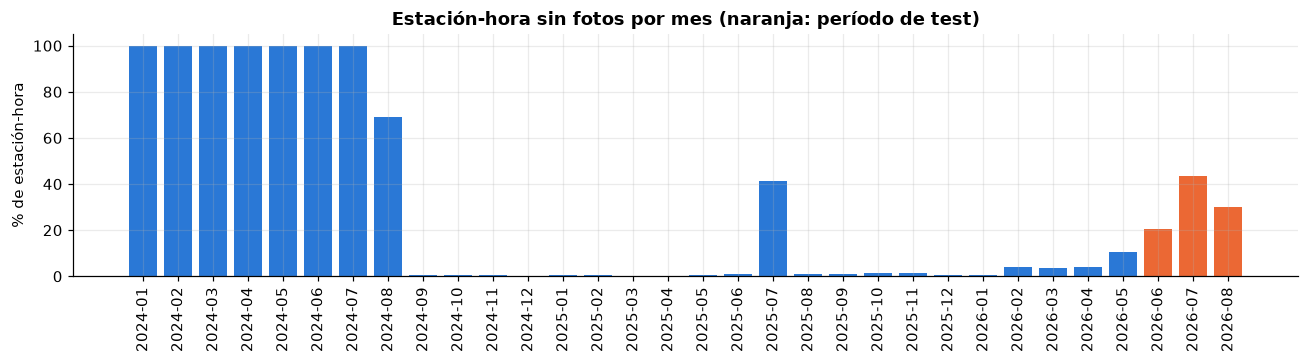

In [23]:
sin_fotos_mes = dataset.groupby(dataset.hora_local.dt.strftime("%Y-%m")).sin_fotos.mean() * 100
fig, ax = plt.subplots(figsize=(12, 3.4))
colores = [ORANGE if mes >= "2026-06" else BLUE for mes in sin_fotos_mes.index]
ax.bar(sin_fotos_mes.index, sin_fotos_mes.values, color=colores, width=0.8)
ax.set(ylabel="% de estación-hora", ylim=(0, 105),
       title="Estación-hora sin fotos por mes (naranja: período de test)")
plt.xticks(rotation=90)
plt.tight_layout()

**Lectura.**

- **Enero a julio de 2024:** 100 % sin fotos (antes de que empezara el scraper, más el hueco de abril a agosto).
- **Julio de 2025:** ~42 % sin fotos, por el hueco del 16 al 28.
- **2026:** entre septiembre de 2024 y enero de 2026 falta menos del 2 %, pero **desde febrero los faltantes crecen**, porque el scraper sacó menos fotos: ~4 % hasta abril, ~11 % en mayo y 21–44 % en el test (junio a agosto).

Las variables de disponibilidad y rotas van a tener muchos faltantes justo en el test. **El target no se ve afectado.**

## 7. Codificación

- `dia_semana` y `franja_horaria` se codifican con **one-hot** (`get_dummies`): son categóricas sin orden útil para un modelo lineal (el domingo no es "más" que el lunes). Se conservan también las columnas originales (`hora`, `dia_semana`) porque a un modelo de árboles le sirven como numéricas.
- No se usa `drop_first`: se guardan todas las categorías y la columna de referencia se elige al modelar si hace falta.
- `station_id` queda como **identificador**, no como variable: con ~400 estaciones, el one-hot agregaría 400 columnas. Las características de la estación ya están en `lat`, `lon` y las variables de capacidad. Si se quiere usar la estación como variable, se decide al modelar (por ejemplo, con *target encoding* calculado sólo con el train).
- `tipo_feriado` queda como categórica descriptiva. Para el modelo alcanza con `es_feriado`.

In [24]:
NOMBRES_DIAS = ["lun", "mar", "mie", "jue", "vie", "sab", "dom"]
dummies = pd.concat([
    pd.get_dummies(pd.Categorical(dataset.dia_semana.map(dict(enumerate(NOMBRES_DIAS))), categories=NOMBRES_DIAS),
                   prefix="dia", dtype="int8"),
    pd.get_dummies(dataset.franja_horaria, prefix="franja", dtype="int8"),
], axis=1)
dataset = pd.concat([dataset, dummies], axis=1)
print(list(dummies.columns))
dataset[["hora_local", "dia_semana", "franja_horaria"] + list(dummies.columns)].head(3)

['dia_lun', 'dia_mar', 'dia_mie', 'dia_jue', 'dia_vie', 'dia_sab', 'dia_dom', 'franja_madrugada', 'franja_mañana', 'franja_mediodia', 'franja_tarde', 'franja_noche']


,hora_local,dia_semana,franja_horaria,dia_lun,dia_mar,dia_mie,dia_jue,dia_vie,dia_sab,dia_dom,franja_madrugada,franja_mañana,franja_mediodia,franja_tarde,franja_noche
0,2024-01-01 07:00:00-03:00,0,mañana,1,0,0,0,0,0,0,0,1,0,0,0
1,2024-01-01 08:00:00-03:00,0,mañana,1,0,0,0,0,0,0,0,1,0,0,0
2,2024-01-01 09:00:00-03:00,0,mañana,1,0,0,0,0,0,0,0,1,0,0,0


## 8. Partición temporal

La demanda es una serie temporal: una partición al azar mezclaría horas contiguas entre train y test, y el test mediría memoria y no predicción. Se usa un **corte temporal**:

- **train:** 01/01/2024 → 31/05/2026 (29 meses; incluye dos inviernos, 2024 y 2025).
- **test:** 01/06/2026 → 31/08/2026 (los últimos tres meses publicados, invierno).

No se entrena ningún modelo: sólo se agrega la columna `split`. Se hace **antes de normalizar** porque la normalización se ajusta sólo con el train.

In [25]:
dataset["split"] = np.where(dataset.hora_local >= TEST_DESDE, "test", "train")
dataset.groupby("split").agg(
    filas=("retiros", "size"),
    desde=("hora_local", "min"),
    hasta=("hora_local", "max"),
    estaciones=("station_id", "nunique"),
    retiros_medios=("retiros", "mean"),
    pct_sin_fotos=("sin_fotos", lambda s: s.mean() * 100),
).round({"retiros_medios": 2, "pct_sin_fotos": 1})

,filas,desde,hasta,estaciones,retiros_medios,pct_sin_fotos
split,,,,,,
test,870753,2026-06-01 00:00:00-03:00,2026-08-31 23:00:00-03:00,396,0.66,31.6
train,8121596,2024-01-01 00:00:00-03:00,2026-05-31 23:00:00-03:00,412,0.95,27.2


## 9. Normalización

Temperatura, viento y precipitación tienen escalas muy distintas (grados, km/h, mm). Se estandarizan con `StandardScaler` (media 0 y desvío 1) **ajustado sólo con el train**: si se ajustara con todo el dataset, la media y el desvío incluirían información del test (el invierno de 2026) y se filtraría información del futuro.

Se agregan como columnas nuevas con sufijo `_std` y se conservan las originales: los modelos de árboles no necesitan escalar y las unidades originales se leen más fácil. Los parámetros se guardan en un archivo para poder aplicar la misma transformación en producción.

In [26]:
COLUMNAS_CLIMA = ["temperatura_c", "precipitacion_mm", "viento_kmh"]
es_train = dataset.split == "train"

escalador = StandardScaler().fit(dataset.loc[es_train, COLUMNAS_CLIMA])
escaladas = escalador.transform(dataset[COLUMNAS_CLIMA]).astype("float32")
for i, columna in enumerate(COLUMNAS_CLIMA):
    dataset[f"{columna}_std"] = escaladas[:, i]

parametros_escalado = pd.DataFrame({"media_train": escalador.mean_, "desvio_train": escalador.scale_}, index=COLUMNAS_CLIMA)
display(parametros_escalado.round(3))
dataset.groupby("split")[[f"{c}_std" for c in COLUMNAS_CLIMA]].agg(["mean", "std"]).round(2)

,media_train,desvio_train
temperatura_c,18.519,6.53
precipitacion_mm,0.128,0.78
viento_kmh,12.610,5.86


temperatura_c_std       precipitacion_mm_std       viento_kmh_std      
                   mean   std                 mean   std           mean   std
split                                                                        
test              -1.13  0.54                -0.05  0.69          -0.47  0.69
train             -0.00  1.00                -0.00  1.00           0.00  1.00

**Lectura.** En el train las variables estandarizadas tienen media 0 y desvío 1 por construcción. En el test la temperatura queda con media negativa: junio a agosto es invierno y está por debajo del promedio anual del train. Es el comportamiento esperado, y la prueba de que el escalador no "vio" el test.

## 10. Selección de variables

| Variable descartada | Motivo |
|---|---|
| Nombres y direcciones de estaciones | Texto redundante con `station_id`, con renombres y espacios sobrantes. El nombre se guarda aparte en la tabla de estaciones |
| `genero`, `id_usuario` | Atributos del usuario, no de la estación-hora. Además no se conocen de antemano al predecir la demanda de una hora futura |
| `modelo_bicicleta`, `id_recorrido`, `duracion_seg` | Atributos del viaje: ya quedaron resumidos en los conteos de retiros y arribos |
| `n_fotos_capacidad_cero`, `n_fotos_sin_alquiler` | Columnas de control usadas en la limpieza y reemplazadas por `sin_alquiler` |
| `capacidad_total` | Intermedia: se usó para `pct_capacidad_rota` |
| `anio_archivo` | Igual al año del viaje |

In [27]:
COLUMNAS_FINALES = (
    ["station_id", "hora_local", "split", "retiros", "arribos"]
    + ["hora", "dia_semana", "mes", "anio", "es_fin_de_semana", "es_feriado", "tipo_feriado", "dia_habil", "franja_horaria"]
    + list(dummies.columns)
    + COLUMNAS_CLIMA + ["llueve"] + [f"{c}_std" for c in COLUMNAS_CLIMA]
    + ["lat", "lon"]
    + ["sin_fotos", "n_fotos", "bicis_disponibles", "bicis_rotas", "anclajes_libres", "anclajes_rotos",
       "capacidad_publicada", "capacidad_util", "pct_capacidad_rota", "prop_vacia", "prop_llena"]
    + list(flags)
)
descartadas = sorted(set(dataset.columns) - set(COLUMNAS_FINALES))
print("Descartadas en este paso:", descartadas)
dataset = dataset[COLUMNAS_FINALES].sort_values(["station_id", "hora_local"], ignore_index=True)
print(f"Dataset final: {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas "
      f"({dataset.memory_usage(deep=True).sum() / 1e9:.2f} GB en memoria)")
dataset.info()

Descartadas en este paso: ['capacidad_total']


Dataset final: 8,992,349 filas × 49 columnas (1.76 GB en memoria)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8992349 entries, 0 to 8992348
Data columns (total 49 columns):
 #   Column                Dtype                                         
---  ------                -----                                         
 0   station_id            int64                                         
 1   hora_local            datetime64[ns, America/Argentina/Buenos_Aires]
 2   split                 object                                        
 3   retiros               int16                                         
 4   arribos               int16                                         
 5   hora                  int8                                          
 6   dia_semana            int8                                          
 7   mes                   int8                                          
 8   anio                  int16                                         
 9   es

## 11. Exportación

In [28]:
dataset.to_parquet(PROCESSED_DIR / "dataset_estacion_hora.parquet", index=False)
estaciones[estaciones.station_id.isin(dataset.station_id)].to_csv(PROCESSED_DIR / "estaciones.csv", index=False)
parametros_escalado.to_csv(PROCESSED_DIR / "parametros_normalizacion.csv", index_label="variable")

pd.DataFrame([
    {"archivo": ruta.relative_to(REPO_DIR).as_posix(), "MB": round(ruta.stat().st_size / 1e6, 1)}
    for ruta in sorted(PROCESSED_DIR.iterdir())
])

,archivo,MB
0,data/processed/dataset_estacion_hora.parquet,96.6
1,data/processed/estaciones.csv,0.0
2,data/processed/parametros_normalizacion.csv,0.0


In [29]:
# Control: el archivo exportado se vuelve a leer igual
releido = pd.read_parquet(PROCESSED_DIR / "dataset_estacion_hora.parquet")
assert releido.shape == dataset.shape
assert releido.retiros.sum() == dataset.retiros.sum()
print("Exportación verificada:", releido.shape)
releido.sample(5, random_state=1)

Exportación verificada: (8992349, 49)


,station_id,hora_local,split,retiros,arribos,hora,dia_semana,mes,anio,es_fin_de_semana,es_feriado,tipo_feriado,dia_habil,franja_horaria,dia_lun,dia_mar,dia_mie,dia_jue,dia_vie,dia_sab,dia_dom,franja_madrugada,franja_mañana,franja_mediodia,franja_tarde,franja_noche,temperatura_c,precipitacion_mm,viento_kmh,llueve,temperatura_c_std,precipitacion_mm_std,viento_kmh_std,lat,lon,sin_fotos,n_fotos,bicis_disponibles,bicis_rotas,anclajes_libres,anclajes_rotos,capacidad_publicada,capacidad_util,pct_capacidad_rota,prop_vacia,prop_llena,flag_vacia,flag_llena_por_rotas,sin_alquiler
4651183,311,2024-07-21 23:00:00-03:00,train,0,0,23,6,7,2024,1,0,no es feriado,0,noche,0,0,0,0,0,0,1,0,0,0,0,1,11.8,0.0,6.5,0,-1.028948,-0.164455,-1.042672,-34.597210,-58.474211,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
8384024,552,2025-12-28 07:00:00-03:00,train,0,0,7,6,12,2025,1,0,no es feriado,0,mañana,0,0,0,0,0,0,1,0,1,0,0,0,24.6,0.0,12.2,0,0.931117,-0.164455,-0.069995,-34.602851,-58.512609,0,4.0,1.0,0.0,15.0,0.0,16.0,16.0,0.000000,0.0,0.0,0,0,0
7550527,509,2026-05-25 20:00:00-03:00,train,0,0,20,0,5,2026,0,1,inamovible,0,noche,1,0,0,0,0,0,0,0,0,0,0,1,13.5,0.0,1.5,0,-0.768627,-0.164455,-1.895897,-34.633638,-58.489810,0,2.0,5.0,0.0,7.0,0.0,12.0,12.0,0.000000,0.0,0.0,0,0,0
5738685,395,2025-12-13 22:00:00-03:00,train,0,0,22,5,12,2025,1,0,no es feriado,0,noche,0,0,0,0,0,1,0,0,0,0,0,1,21.9,0.0,18.7,0,0.517665,-0.164455,1.039197,-34.596849,-58.453280,0,2.0,10.0,2.0,4.0,0.0,16.0,14.0,0.125000,0.0,0.0,0,0,0
2792291,183,2026-08-18 00:00:00-03:00,test,0,1,0,1,8,2026,0,0,no es feriado,1,madrugada,0,1,0,0,0,0,0,1,0,0,0,0,10.2,0.0,18.4,0,-1.273956,-0.164455,0.988004,-34.615699,-58.389973,0,1.0,19.0,2.0,7.0,0.0,28.0,26.0,0.071429,0.0,0.0,0,0,0


### 11.1 Diccionario de datos del dataset final

**`data/processed/dataset_estacion_hora.parquet`**: una fila por estación activa y hora, del 01/01/2024 al 31/08/2026.

| Variable | Tipo | Significado |
|---|---|---|
| `station_id` | entero | Estación (identificador, no variable). Cruza con `estaciones.csv` |
| `hora_local` | fecha y hora (Buenos Aires) | Inicio de la hora |
| `split` | texto | `train` (hasta el 31/05/2026) o `test` (junio a agosto de 2026) |
| **`retiros`** | entero | **Target.** Viajes que salieron de la estación en esa hora (0 si no hubo) |
| `arribos` | entero | Viajes que llegaron a la estación en esa hora (0 si no hubo) |
| `hora`, `dia_semana`, `mes`, `anio` | entero | Calendario (`dia_semana`: 0 = lunes) |
| `es_fin_de_semana`, `es_feriado`, `dia_habil` | 0/1 | Tipo de día. `es_feriado` incluye puentes y días no laborables |
| `tipo_feriado` | categórica | `inamovible`, `trasladable`, `puente`, `no laborable` o `no es feriado` |
| `franja_horaria` | categórica | `madrugada` (0–5), `mañana` (6–9), `mediodia` (10–15), `tarde` (16–19), `noche` (20–23) |
| `dia_lun` … `dia_dom` | 0/1 | One-hot del día de la semana |
| `franja_madrugada` … `franja_noche` | 0/1 | One-hot de la franja horaria |
| `temperatura_c`, `precipitacion_mm`, `viento_kmh` | decimal | Clima observado en la hora (Open-Meteo) |
| `llueve` | 0/1 | Precipitación > 0 en la hora |
| `temperatura_c_std`, `precipitacion_mm_std`, `viento_kmh_std` | decimal | Clima estandarizado con media y desvío del train |
| `lat`, `lon` | decimal | Última ubicación publicada de la estación, con el signo de la latitud corregido |
| `sin_fotos` | 0/1 | 1 si no hay fotos válidas de la estación en esa hora: las variables de abajo quedan en NaN |
| `n_fotos` | decimal | Fotos de la estación en la hora |
| `bicis_disponibles`, `bicis_rotas` | decimal | Promedio de bicis disponibles y rotas en la hora |
| `anclajes_libres`, `anclajes_rotos` | decimal | Promedio de anclajes libres y fuera de servicio |
| `capacidad_publicada` | decimal | Promedio de `capacity` del feed |
| `capacidad_util` | decimal | Bicis disponibles + anclajes libres |
| `pct_capacidad_rota` | decimal (0–1) | Parte de la capacidad ocupada por bicis rotas o anclajes rotos |
| `prop_vacia`, `prop_llena` | decimal (0–1) | Fracción de las fotos con 0 bicis disponibles o 0 anclajes libres |
| `flag_vacia` | 0/1/nulo | Vacía en ≥ 50 % de las fotos: retiros censurados |
| `flag_llena_por_rotas` | 0/1/nulo | Llena en ≥ 50 % de las fotos y con ≥ 1 bici rota: arribos censurados |
| `sin_alquiler` | 0/1/nulo | Alguna foto con la estación sin alquilar |

**`data/processed/estaciones.csv`**: `station_id`, `nombre` (último publicado), `lat`, `lon`.

**`data/processed/parametros_normalizacion.csv`**: media y desvío del train de cada variable de clima.

## 12. Reflexión final

### 12.1 Decisiones tomadas y su justificación

| Decisión | Justificación |
|---|---|
| Target = **retiros reales** de BA Data y no el proxy de las fotos | El proxy captura ~66 % de los retiros cuando las fotos son buenas y 22 % en 2026. Los viajes miden la demanda atendida sin depender del scraper |
| Nivel **estación × hora** | Es lo que pide la propuesta. Con la grilla completa se pueden agregar después a estación-día o red-hora sin volver a procesar |
| **Grilla completa con ceros** dentro de la ventana activa de cada estación | Sin ella las horas sin retiros no existen. Con la ventana activa no se inventan ceros de estaciones que todavía no existían |
| Sacar las horas sin viajes en toda la red | Son cortes del sistema, no demanda nula |
| Mismos filtros de duración para todos los años (61 s a 24 h) y sin vueltas de < 2 min | BA Data limpió distinto según el año. Sin esto, 2024 tendría ~10 % más "viajes" que no son viajes |
| Fotos: descartar abril de 2024 y las horas con `capacity = 0`; conservar `is_renting = False` como flag | Las primeras son datos inválidos o aislados. La estación cerrada es información: explica un cero |
| **No imputar** las horas sin fotos | Los huecos son bloques de meses: una mediana inventaría disponibilidad no observada. `sin_fotos` lo deja explícito |
| Flags de demanda censurada | Responde al feedback de la cátedra: una estación vacía, o llena de bicis rotas, no registra la demanda que tiene |
| Jueves Santo como no laborable | Los viajes muestran que se comporta como feriado y la API no lo trae |
| Corte temporal y escalador ajustado sólo con el train | Evita filtrar información del futuro al test |

### 12.2 Dificultades

- **Tres esquemas distintos de BA Data** (BOM, sufijo `BAEcobici`, separador de miles, encabezados) y **criterios de limpieza distintos por año**, que sólo se ven al comparar distribuciones entre años.
- **Volumen:** 21 M de fotos y 8,7 M de viajes no entran cómodos en pandas en cualquier máquina. Se resolvió leyendo y agregando con DuckDB y convirtiendo los CSV a parquet una sola vez.
- **Calidad del scraper:** el hueco de abril a agosto de 2024, el de julio de 2025 y la degradación de 2026 hacen que las variables de estado de estación falten justo en el test.
- **Identidad de las estaciones:** renombres, nombres compartidos entre `station_id`, mudanzas, capacidad variable y un error de signo en la latitud. Se resolvió trabajando siempre con `station_id`. Además, los viajes incluyen movimientos a depósitos y talleres que no son estaciones públicas: se detectaron cruzando con el feed.
- **Demanda censurada:** los viajes sólo muestran la demanda que se pudo atender. Separar "no hubo demanda" de "no hubo bicis" requirió cruzar dos fuentes.

### 12.3 Siguientes pasos

1. **Variables con rezago:** el estado de la estación en la hora anterior (bicis disponibles y rotas) y la demanda de la misma hora del día y de la semana anteriores. Son las que se pueden conocer en el momento de predecir. Hay que calcularlas sobre la grilla completa, por estación.
2. **Clima pronosticado en lugar de observado:** en producción sólo va a haber pronóstico. Hay que evaluar cuánto empeora el modelo con los pronósticos del repositorio de las fotos (quedándose con la versión más cercana a cada hora).
3. **Tratamiento de la censura al entrenar:** comparar entrenar sin las horas censuradas contra usar los flags como variables.
4. **Modelo base:** empezar con un promedio por estación, día y franja como referencia, y seguir con un modelo de árboles con pérdida de Poisson, que acepta los NaN de las fotos.
5. **Variables espaciales:** metros de ciclovía cerca de cada estación (con `geopandas`) y detección de estaciones que se mudaron más de 100 m.
6. **Actualización:** cuando BA Data publique septiembre de 2026, basta con volver a correr los tres notebooks.

### 12.4 Pendientes del plan

- **Último día de los viajes de 2026:** confirmado, 31/08/2026 (sección 3).
- **Notebook template de la cátedra:** todavía no lo tenemos. Las secciones siguen el enunciado; si aparece el template, sólo cambian los títulos.